<a href="https://colab.research.google.com/github/Cstrack96/894462/blob/main/Bases_Act_Trabajo_Pr%C3%A1ctico_1_-_894462.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Selección del Par de Divisas y Datos de Mercado**

In [ ]:
# Defino cotización ARS/USD
TC_vendedor_ARS_USD = 1400.00
TC_comprador_ARS_USD = 1350.00

# Defino Tasas de Interés
tasa_inv_ARS_TNA = 0.251

# Tasa de Financiamiento ARS
tasa_fin_ARS_TNA = 0.3791

# Tasa de Inversión USD
tasa_inv_USD_TNA = 0.0368

# Tasa de Financiamiento USD
tasa_fin_USD_TNA = 0.0545

print(f"\n--- Datos de Mercado al cierre 21/04/2026 ---")
print(f"TC Vendedor ARS/USD: ${TC_vendedor_ARS_USD:.2f}")
print(f"TC Comprador ARS/USD: ${TC_comprador_ARS_USD:.2f}")
print(f"Tasa de Inversión ARS (TNA): {tasa_inv_ARS_TNA*100:.2f}%")
print(f"Tasa de Financiamiento ARS (TNA): {tasa_fin_ARS_TNA*100:.2f}%")
print(f"Tasa de Inversión USD (TNA): {tasa_inv_USD_TNA*100:.2f}%")
print(f"Tasa de Financiamiento USD (TNA): {tasa_fin_USD_TNA*100:.2f}%")


--- Datos de Mercado al cierre 21/04/2026 ---
TC Vendedor ARS/USD: $1400.00
TC Comprador ARS/USD: $1350.00
Tasa de Inversión ARS (TNA): 25.10%
Tasa de Financiamiento ARS (TNA): 37.91%
Tasa de Inversión USD (TNA): 3.68%
Tasa de Financiamiento USD (TNA): 5.45%


####**Analisis de Arbitraje con Futuro divisas**



In [ ]:
# Definimos la clase ValuacionActivo para organizar el cálculo del precio teórico.
# Esta clase guarda los datos necesarios (Spot, Tasas y Plazo) y aplica la fórmula de equilibrio.

class ValuacionActivo:
    def __init__(self, spot, tasa_ars, tasa_usd, plazo_dias):
        self.spot = spot  # Precio actual del activo (Spot)
        self.tasa_ars = tasa_ars
        self.tasa_usd = tasa_usd
        self.plazo_dias = plazo_dias

    def precio_teorico(self):
        # Convertimos el plazo de días a una fracción de año (base 365 para TNAs)
        T = self.plazo_dias / 365

        # Precio Forward = Spot * (1 + tasa_pesos * tiempo) / (1 + tasa_dolar * tiempo)
        resultado = self.spot * (1 + self.tasa_ars * T) / (1 + self.tasa_usd * T)

        return resultado


In [ ]:
# Cálculo del precio teórico:
# 1. A 90 días,
# 2. A 101 días para evaluar la posibilidad de arbitraje,
# 3.

# Definimos el precio de mercado del futuro DOJUL2026 al 21/04/2026
precio_mercado_DOJUL2026 = 1457.50

# Definimos el plazo de días al vencimiento del futuro.
plazo_dias = 101

# 1. Cálculo del Forward Teórico a 90 días
modelo_90d = ValuacionActivo(
    spot=TC_vendedor_ARS_USD,
    tasa_ars=tasa_inv_ARS_TNA,
    tasa_usd=tasa_inv_USD_TNA,
    plazo_dias=90
)
precio_90d = modelo_90d.precio_teorico()

# 2. Precio Teórico del Forward (a 101 días)
# Es el punto de indiferencia donde a un inversor le daría lo mismo colocar sus pesos
# a la tasa local (tasa_ars) o comprar dólares y ponerlos a rendir (tasa_usd).
modelo_teorico = ValuacionActivo(
    spot=TC_vendedor_ARS_USD,
    tasa_ars=tasa_inv_ARS_TNA,
    tasa_usd=tasa_inv_USD_TNA,
    plazo_dias=plazo_dias
)
precio_forward_teorico = modelo_teorico.precio_teorico()

# 3. Banda de No Arbitraje (Piso y Techo)
# Uso esta clase para calcular una banda de no arbitraje: si el precio del futuro cae dentro,
# se considera que el mercado está en equilibrio y no hay oportunidades de arbitraje.

# Escenario Venta (Techo)
# Armé este escenario para encontrar el precio más alto que aguantaría el futuro.
# La idea es ver qué pasa si un operador pide pesos prestados (tasa de financiamiento)
# para comprar dólares hoy y ponerlos a rendir (tasa de inversión). Si el futuro
# en el mercado está más caro que este "techo", hay una oportunidad para vender.
modelo_venta = ValuacionActivo(
    spot=TC_vendedor_ARS_USD,
    tasa_ars=tasa_fin_ARS_TNA,
    tasa_usd=tasa_inv_USD_TNA,
    plazo_dias=plazo_dias
)
precio_techo = modelo_venta.precio_teorico()

# Escenario Compra (Piso)
# Defino este escenario para calcular el precio más bajo posible para el futuro (el "piso").
# Acá la lógica es al revés: el operador vende sus dólares para poner los pesos a tasa
# de inversión, pero tiene que bancar el costo de pedir prestados esos dólares
# (tasa de financiamiento). Si el mercado cae por debajo de este valor, conviene comprar.
modelo_compra = ValuacionActivo(
    spot=TC_comprador_ARS_USD,
    tasa_ars=tasa_inv_ARS_TNA,
    tasa_usd=tasa_fin_USD_TNA,
    plazo_dias=plazo_dias
)
precio_piso = modelo_compra.precio_teorico()

print(f"Precio Forward Teórico (90 días):  ${precio_90d:.2f}")
print(f"-"*40)
print(f"--- RESULTADOS AL 21/04/2026 (Plazo: {plazo_dias} días) ---")
print(f"1. Cotización Mercado DOJUL2026: ${precio_mercado_DOJUL2026:.2f}")
print(f"2. Precio Forward Teórico (Equilibrio): ${precio_forward_teorico:.2f}")
print(f"3. Banda de No Arbitraje: [${precio_piso:.2f} - ${precio_techo:.2f}]")
print(f"-"*40)

if precio_mercado_DOJUL2026 > precio_techo:
    print(f"HAY ARBITRAJE DE VENTA")
elif precio_mercado_DOJUL2026 < precio_piso:
    print(f"HAY ARBITRAJE DE COMPRA")
else:
    print(f"NO HAY OPORTUNIDAD DE ARBITRAJE")
    print(f"El precio se encuentra dentro de la banda.")

Precio Forward Teórico (90 días):  $1473.28
----------------------------------------
--- RESULTADOS AL 21/04/2026 (Plazo: 101 días) ---
1. Cotización Mercado DOJUL2026: $1457.50
2. Precio Forward Teórico (Equilibrio): $1482.14
3. Banda de No Arbitraje: [$1422.31 - $1531.27]
----------------------------------------
NO HAY OPORTUNIDAD DE ARBITRAJE
El precio se encuentra dentro de la banda.


####**Analisis de Arbitraje con Futuro GGAL**



In [ ]:
# 1. Datos del Mercado para la acción GGAL al 21/04/2026 y plazo de
# días al vencimiento del futuro (19/06/2026)
spot_ggal = 7010.00
ajuste_futuro_ggal = 7355.00
plazo_arbitraje_ggal = 59

# 2. Defino Dividendos
div_por_accion = 93.3851
fecha_pago_div = 17 # Días desde el 21/04 al 08/05

# 3. Defino las nuevas tasas
tasa_inv_ars_S17L6 = 0.2424
tasa_fin_ars = 0.3881
T_ggal = plazo_arbitraje_ggal / 365

# Valor Presente del Dividendo (I) usando la tasa de la LECAP S17L6
I = div_por_accion / (1 + tasa_inv_ars_S17L6 * (fecha_pago_div/365))

# 4. Precio Teórico
# Calculo el precio teórico como referencia, usando el promedio de las tasas.
tasa_promedio = (tasa_inv_ars_S17L6 + tasa_fin_ars) / 2
precio_teorico_ggal = (spot_ggal - I) * (1 + tasa_promedio * T_ggal)

# 5. Calculo el precio teórico para analizar arbitraje
# de compra o venta.
# Piso: (S - I) capitalizado a tasa de inversión
precio_piso_ggal = (spot_ggal - I) * (1 + tasa_inv_ars_S17L6 * T_ggal)

# Techo: (S - I) capitalizado a tasa de financiamiento
precio_techo_ggal = (spot_ggal - I) * (1 + tasa_fin_ars * T_ggal)

# 6. RESULTADOS
print(f"ANÁLISIS DE ARBITRAJE (CON DIVIDENDOS): GGAL ")
print(f"Dividendo por acción (I): ${div_por_accion:.4f}")
print(f"V.A. de Dividendo por acción (I): ${I:.4f}")
print(f"Precio Teórico: ${precio_teorico_ggal:.2f}")
print(f"Banda de No Arbitraje: [${precio_piso_ggal:.2f} - ${precio_techo_ggal:.2f}]")
print(f"Precio Mercado Futuro: ${ajuste_futuro_ggal:.2f}")
print("-" * 40)

if ajuste_futuro_ggal < precio_piso_ggal:
    print("Oportunidad de Arbitraje Venta")
elif ajuste_futuro_ggal > precio_techo_ggal:
    print("Oportunidad de Arbitraje Venta")
else:
    print("No hay oportunidad de arbitraje")

ANÁLISIS DE ARBITRAJE (CON DIVIDENDOS): GGAL 
Dividendo por acción (I): $93.3851
V.A. de Dividendo por acción (I): $92.3426
Precio Teórico: $7270.17
Banda de No Arbitraje: [$7188.71 - $7351.63]
Precio Mercado Futuro: $7355.00
----------------------------------------
Oportunidad de Arbitraje Venta


##**2. Estrategia de "Target Beta" con Futuros de Índice**


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings

# Silenciar avisos de actualizaciones futuras
warnings.filterwarnings('ignore')

# 1. Defino mi Cartera y beta objetivo
# Monto: $100.000.000
monto_total = 100_000_000
beta_objetivo = 0.5
tickers = ['CEPU.BA', 'BYMA.BA', 'PAMP.BA', 'TGSU2.BA', 'BMA.BA']
benchmark = '^MERV' # S&P Merval
pesos = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# 2. Descarga los precios de la librería yfinance
data = yf.download(tickers + [benchmark], start='2023-04-22', end='2026-04-22')
precios = data['Adj Close'] if 'Adj Close' in data.columns else data['Close']
retornos = precios.pct_change().dropna()

# 3. Cálculo de Retornos de la Cartera
# Multiplicamos los retornos de cada acción por su peso
retornos['CARTERA'] = retornos[tickers].dot(pesos)

# 4. Cálculo de Betas
retornos_merval = retornos[benchmark]
var_mkt = retornos_merval.var()

betas_ind = {}
for t in tickers:
    cov = retornos[t].cov(retornos_merval)
    betas_ind[t] = cov / var_mkt

beta_cartera = sum(betas_ind[t] * pesos[i] for i, t in enumerate(tickers))

# 5. Cálculo del Hedge Ratio Error
X = sm.add_constant(retornos[benchmark]) # Agregamos la constante para la regresión
modelo = sm.OLS(retornos['CARTERA'], X).fit()
r_cuadrado = modelo.rsquared
hedge_error = 1 - r_cuadrado

# 6. Cálculo de Contratos
# Valor del contrato de futuro (ejemplo basado en precio actual)
val_futuro = 450500
v_f = val_futuro * 1 # Multiplicador del contrato
n_contratos = ((beta_objetivo - beta_cartera) * monto_total) / v_f

# 7. Resultados
print("\n" + "="*50)
print("        BETAS INDIVIDUALES")
print("="*50)
print(f"{'Activo':<10} | {'Beta':<8} | {'Contribución a Cartera':<15}")
print("-" * 50)
for i, t in enumerate(tickers):
    b_i = betas_ind[t]
    contribucion = b_i * pesos[i]
    print(f"{t:<10} | {b_i:<8.2f} | {contribucion:<15.2f}")

print("-" * 50)
print(f"BETA TOTAL DE LA CARTERA: {beta_cartera:.2f}")
print(f"CONTRATOS A OPERAR: {round(n_contratos)}")
print("="*50)


shock = 0.10
print(f"\nAnálisis de Sensibilidad (Merval +10%) ")
print(f" Impacto Cartera Original: ${monto_total * beta_cartera * shock:,.2f}")
print(f" Impacto Cartera Protegida: ${monto_total * beta_objetivo * shock:,.2f}")
print("="*50 + "\n")

print(f"\nEficacia y Error de Cobertura")
print(f" R-cuadrado (Eficacia): {r_cuadrado:.4f}")
print(f" Hedge Ratio Error: {hedge_error:.4f}")

[*********************100%***********************]  6 of 6 completed


        BETAS INDIVIDUALES
Activo     | Beta     | Contribución a Cartera
--------------------------------------------------
CEPU.BA    | 1.10     | 0.22           
BYMA.BA    | 0.83     | 0.17           
PAMP.BA    | 0.92     | 0.18           
TGSU2.BA   | 1.11     | 0.22           
BMA.BA     | 1.14     | 0.23           
--------------------------------------------------
BETA TOTAL DE LA CARTERA: 1.02
CONTRATOS A OPERAR: -115

Análisis de Sensibilidad (Merval +10%) 
 Impacto Cartera Original: $10,201,075.98
 Impacto Cartera Protegida: $5,000,000.00


Eficacia y Error de Cobertura
 R-cuadrado (Eficacia): 0.9362
 Hedge Ratio Error: 0.0638


## **Evolución de Beta de Cartera**

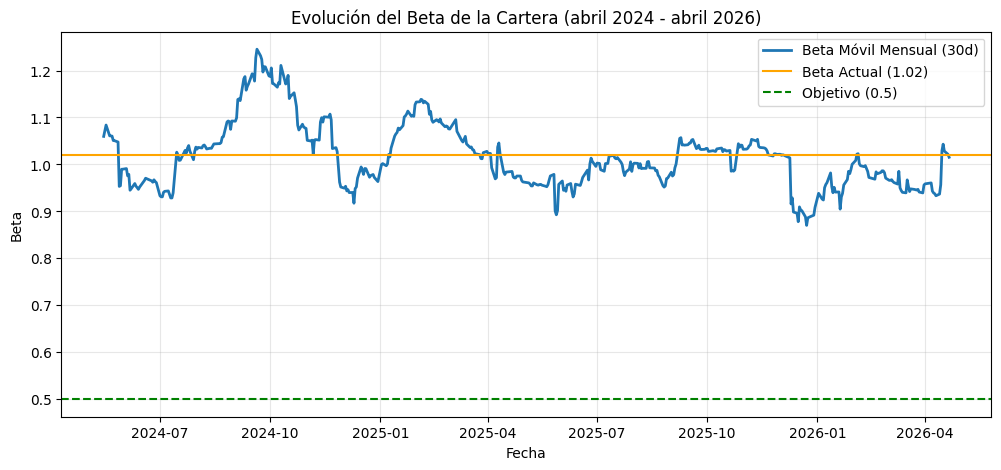

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filtramos los retornos desde abril 2024
retornos_recientes = retornos.loc['2024-04-01':]

# 2. Ventana de 30 días para ver el comportamiento mensual
window_mensual = 30

# 3. Cálculo del Rolling Beta
betas_mensuales = pd.DataFrame()
for t in tickers:
    rolling_cov = retornos_recientes[t].rolling(window=window_mensual).cov(retornos_recientes[benchmark])
    rolling_var = retornos_recientes[benchmark].rolling(window=window_mensual).var()
    betas_mensuales[t] = rolling_cov / rolling_var

# Beta de la cartera (producto punto entre betas individuales y sus pesos)
betas_mensuales['Cartera'] = betas_mensuales[tickers].dot(pesos)

# 4. Gráfico enfocado
plt.figure(figsize=(12, 5))

plt.plot(betas_mensuales['Cartera'].dropna(), label='Beta Móvil Mensual (30d)', color='#1f77b4', lw=2)

plt.axhline(y=beta_cartera, color='orange', linestyle='-', label=f'Beta Actual ({beta_cartera:.2f})')
plt.axhline(y=0.5, color='green', linestyle='--', label='Objetivo (0.5)')

plt.title('Evolución del Beta de la Cartera (abril 2024 - abril 2026)')
plt.xlabel('Fecha')
plt.ylabel('Beta')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **Curva de Sensibilidad**

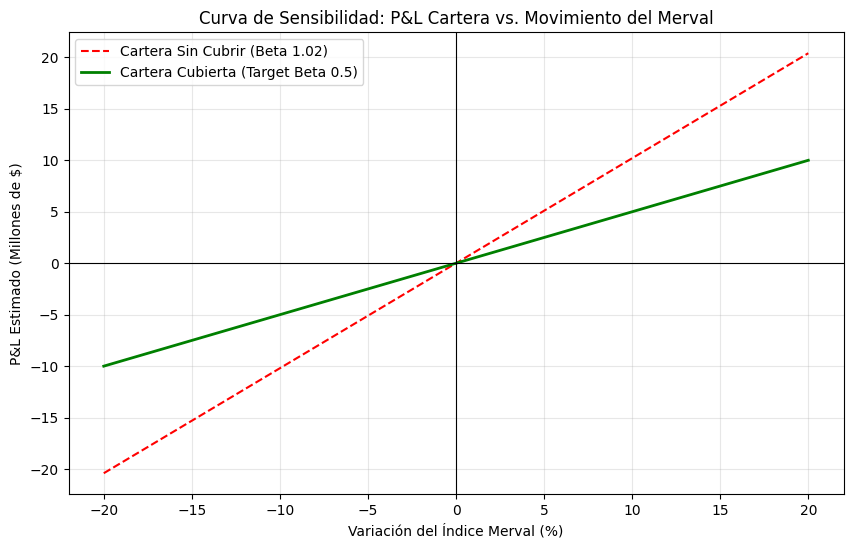




     RESUMEN DE SENSIBILIDAD (P&L EN MILLONES)
Var. Merval  | P&L Sin Cubrir     | P&L Cubierto      
------------------------------------------------------------
       -20% | $         -20.40M | $         -10.00M
       -10% | $         -10.20M | $          -5.00M
        10% | $          10.20M | $           5.00M
        20% | $          20.40M | $          10.00M



In [ ]:
# 1. Defino el rango de movimientos del mercado
variaciones_merval = np.linspace(-0.20, 0.20, 41) # De -20% a +20% en pasos de 1%

# 2. Calcular P&L para Cartera Sin Cubrir (Beta 1.02)
pnl_sin_cubrir = monto_total * beta_cartera * variaciones_merval

# 3. Calcular P&L de la Cobertura (Futuros)
pnl_futuros = n_contratos * v_f * variaciones_merval

# 4. Calcular P&L de la Cartera Cubierta (Neto)
pnl_cubierta = pnl_sin_cubrir + pnl_futuros

# 5. Graficar la curva de sensibilidad
plt.figure(figsize=(10, 6))
plt.plot(variaciones_merval * 100, pnl_sin_cubrir / 1e6, 'r--', label='Cartera Sin Cubrir (Beta 1.02)')
plt.plot(variaciones_merval * 100, pnl_cubierta / 1e6, 'g-', linewidth=2, label='Cartera Cubierta (Target Beta 0.5)')

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Curva de Sensibilidad: P&L Cartera vs. Movimiento del Merval')
plt.xlabel('Variación del Índice Merval (%)')
plt.ylabel('P&L Estimado (Millones de $)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Tabla Comparativa: Análisis de Sensibilidad
print("\n" * 2)
print("="*60)
print("     RESUMEN DE SENSIBILIDAD (P&L EN MILLONES)")
print("="*60)
print(f"{'Var. Merval':<12} | {'P&L Sin Cubrir':<18} | {'P&L Cubierto':<18}")
print("-" * 60)

for v in [-0.20, -0.10, 0.10, 0.20]:
    sin = (monto_total * beta_cartera * v) / 1e6
    con = (monto_total * beta_cartera * v + n_contratos * v_f * v) / 1e6
    print(f"{v*100:>10.0f}% | ${sin:>15.2f}M | ${con:>15.2f}M")
print("="*60 + "\n")